# Notebook 08: Setup & Test Qwen2.5-VL-7B

## Objectif
Charger le modèle Qwen2.5-VL-7B-Instruct et tester l'inférence sur des échantillons du dataset CassavaVLM pour:
- Valider l'installation et la compatibilité
- Établir une baseline zero-shot avant fine-tuning
- Mesurer la latence d'inférence
- Inspecter l'architecture du modèle

## Dataset Status
- **Total images**: 30,491
- **Splits**: Train (24,392) / Val (3,049) / Test (3,050)
- **Format**: Qwen2.5-VL JSONL avec conversations multimodales
- **Classes**: 5 (CBB, CBSD, CGM, CMD, Healthy)

## Hardware
- **GPU**: NVIDIA RTX 5090 32GB VRAM
- **CUDA**: 12.9
- **Expected VRAM**: ~16-18GB pour Qwen2.5-VL-7B en FP16

## 1. Imports & Setup

In [1]:
import torch
import json
import time
import random
from pathlib import Path
from PIL import Image
from transformers import AutoModelForVision2Seq, AutoProcessor
from qwen_vl_utils import process_vision_info
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration des paths
PROJECT_ROOT = Path("/home/hounfodjidagba/learning/cassava")
VLM_DATASET_DIR = PROJECT_ROOT / "outputs" / "vlm_dataset"
IMAGES_DIR = VLM_DATASET_DIR / "images"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "model_setup"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Vérifier CUDA disponible
print("="*70)
print("CONFIGURATION HARDWARE")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"VRAM libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")
else:
    print("⚠️ CUDA non disponible - utilisation CPU")
print("="*70)

CONFIGURATION HARDWARE
PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5090
Total VRAM: 31.36 GB
VRAM libre: 31.36 GB


## 2. Chargement du Dataset Info

In [2]:
# Charger les métadonnées du dataset
dataset_info_path = VLM_DATASET_DIR / "dataset_info.json"
class_mapping_path = VLM_DATASET_DIR / "class_mapping.json"

with open(dataset_info_path, 'r') as f:
    dataset_info = json.load(f)

with open(class_mapping_path, 'r') as f:
    class_mapping = json.load(f)

print("="*70)
print("DATASET VLM - INFORMATIONS")
print("="*70)
print(f"Nom: {dataset_info['name']}")
print(f"Version: {dataset_info['version']}")
print(f"Total images: {dataset_info['total_images']:,}")
print(f"Image size: {dataset_info['image_size']}")
print(f"Nombre de classes: {dataset_info['num_classes']}")
print("\nSplits:")
for split, info in dataset_info['splits'].items():
    print(f"  - {split}: {info['num_samples']:,} ({info['percentage']:.1f}%)")

print("\nDistribution des classes:")
for class_name, info in dataset_info['class_distribution'].items():
    print(f"  - {class_name}: {info['count']:,} ({info['percentage']:.1f}%)")

print("\nPreprocessing:")
print(f"  - Primary pipeline: {dataset_info['preprocessing']['primary_pipeline']}")
print(f"  - Fallback pipeline: {dataset_info['preprocessing']['fallback_pipeline']}")
print(f"  - Success rate: {dataset_info['preprocessing']['success_rate']}")
print("="*70)

DATASET VLM - INFORMATIONS
Nom: CassavaVLM
Version: 1.0
Total images: 30,491
Image size: [448, 448]
Nombre de classes: 5

Splits:
  - train: 24,392 (80.0%)
  - val: 3,049 (10.0%)
  - test: 3,050 (10.0%)

Distribution des classes:
  - CBB: 1,087 (3.6%)
  - CBSD: 5,186 (17.0%)
  - CGM: 2,386 (7.8%)
  - CMD: 18,136 (59.5%)
  - Healthy: 3,696 (12.1%)

Preprocessing:
  - Primary pipeline: 28995 images (95.0%)
  - Fallback pipeline: 1496 images (4.9%)
  - Success rate: 99.93%


In [3]:
print("="*70)
print("CHARGEMENT DU MODÈLE QWEN2.5-VL-7B-INSTRUCT")
print("="*70)

model_name = "Qwen/Qwen2.5-VL-7B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Modèle: {model_name}")
print(f"Device: {device}")
print("Chargement en cours... (peut prendre quelques minutes)\n")

start_time = time.time()

# Charger le modèle avec dtype="auto" pour utiliser bfloat16/float16 automatiquement
model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)

# Charger le processor
processor = AutoProcessor.from_pretrained(model_name)

load_time = time.time() - start_time

print(f"✓ Modèle chargé en {load_time:.2f}s")
print(f"✓ Processor chargé")
print(f"✓ Nombre de paramètres: {model.num_parameters() / 1e9:.2f}B")
print(f"✓ Type de données: {model.dtype}")

# Vérifier VRAM consommée
if torch.cuda.is_available():
    vram_used = torch.cuda.memory_allocated(0) / 1024**3
    vram_reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"\nVRAM utilisée: {vram_used:.2f} GB")
    print(f"VRAM réservée: {vram_reserved:.2f} GB")
    print(f"VRAM disponible: {32 - vram_reserved:.2f} GB")

print("="*70)

CHARGEMENT DU MODÈLE QWEN2.5-VL-7B-INSTRUCT
Modèle: Qwen/Qwen2.5-VL-7B-Instruct
Device: cuda
Chargement en cours... (peut prendre quelques minutes)



Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


✓ Modèle chargé en 9.68s
✓ Processor chargé
✓ Nombre de paramètres: 8.29B
✓ Type de données: torch.bfloat16

VRAM utilisée: 15.45 GB
VRAM réservée: 15.45 GB
VRAM disponible: 16.55 GB


## 3. Téléchargement et Chargement du Modèle Qwen2.5-VL-7B

Chargement du modèle `Qwen/Qwen2.5-VL-7B-Instruct` en FP16 pour optimiser l'utilisation VRAM.

## 4. Inspection de l'Architecture du Modèle

In [4]:
print("="*70)
print("ARCHITECTURE DU MODÈLE")
print("="*70)

# Compter les paramètres totaux
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Paramètres totaux: {total_params:,} ({total_params/1e9:.2f}B)")
print(f"Paramètres entraînables: {trainable_params:,}")
print(f"Pourcentage entraînable: {trainable_params/total_params*100:.2f}%")

print("\nComposants principaux:")
for name, module in model.named_children():
    num_params = sum(p.numel() for p in module.parameters())
    print(f"  - {name}: {num_params:,} paramètres ({num_params/1e9:.2f}B)")

print("\nStructure du modèle (premiers niveaux):")
print(model)

print("="*70)

ARCHITECTURE DU MODÈLE
Paramètres totaux: 8,292,166,656 (8.29B)
Paramètres entraînables: 8,292,166,656
Pourcentage entraînable: 100.00%

Composants principaux:
  - model: 7,747,169,280 paramètres (7.75B)
  - lm_head: 544,997,376 paramètres (0.54B)

Structure du modèle (premiers niveaux):
Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
         

## 5. Test d'Inférence Zero-Shot (Baseline)

Tester le modèle sans fine-tuning sur un échantillon du dataset pour établir la baseline.

In [5]:
# Fonction utilitaire pour charger des échantillons du JSONL
def load_sample_from_jsonl(jsonl_path, num_samples=1):
    """Charger des échantillons aléatoires depuis un fichier JSONL"""
    samples = []
    with open(jsonl_path, 'r') as f:
        all_lines = f.readlines()
        selected_lines = random.sample(all_lines, min(num_samples, len(all_lines)))
        for line in selected_lines:
            samples.append(json.loads(line))
    return samples

print("✓ Fonction utilitaire définie")

✓ Fonction utilitaire définie


TEST INFÉRENCE ZERO-SHOT

Échantillon ID: val_1617095649855.jpg
Classe: CBSD
Label: 1

Image: 1617095649855.jpg.png
Dimensions: (448, 448)

Question:
Analyze this cassava leaf image and identify any disease present. Provide the disease name and a brief description.

Ground Truth:
Disease: Cassava Brown Streak Disease (CBSD)

Cassava Brown Streak Disease (CBSD) causes brown streaks on stems and necrosis in tubers, severely affecting yield....


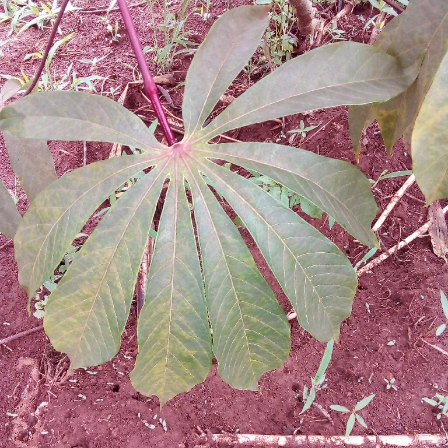

In [6]:
# Charger un échantillon du validation set
val_jsonl = VLM_DATASET_DIR / "val.jsonl"
sample = load_sample_from_jsonl(val_jsonl, num_samples=1)[0]

print("="*70)
print("TEST INFÉRENCE ZERO-SHOT")
print("="*70)
print(f"\nÉchantillon ID: {sample['id']}")
print(f"Classe: {sample['metadata']['class_short']}")
print(f"Label: {sample['metadata']['label']}")

# Charger l'image
image_path = VLM_DATASET_DIR / sample['image']
image = Image.open(image_path)

print(f"\nImage: {image_path.name}")
print(f"Dimensions: {image.size}")

# Extraire la question et la réponse ground truth
question = sample['conversations'][0]['value'].replace('<image>\n', '')
ground_truth = sample['conversations'][1]['value']

print(f"\nQuestion:\n{question}")
print(f"\nGround Truth:\n{ground_truth[:200]}...")  # Afficher les 200 premiers caractères

# Afficher l'image
display(image)

In [7]:
# Préparer l'input pour le modèle
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,  # Passer l'objet PIL Image directement
            },
            {"type": "text", "text": question},
        ],
    }
]

# Préparer pour l'inférence
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(device)

print("\nGénération de la réponse zero-shot...")
start_time = time.time()

# Générer la réponse
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,  # Greedy decoding pour baseline reproductible
    )

inference_time = time.time() - start_time

generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]

print(f"\nTemps d'inférence: {inference_time:.2f}s")
print("\n" + "="*70)
print("RÉPONSE ZERO-SHOT GÉNÉRÉE")
print("="*70)
print(output_text)
print("="*70)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Génération de la réponse zero-shot...

Temps d'inférence: 3.17s

RÉPONSE ZERO-SHOT GÉNÉRÉE
The image shows a cassava leaf with a healthy appearance, displaying the typical compound leaf structure of cassava (Manihot esculenta). There are no visible signs of disease such as spots, blight, or discoloration that would indicate a specific disease. However, it's important to note that visual inspection alone is not always sufficient for diagnosing plant diseases, especially in the early stages.

To accurately diagnose a disease, it's recommended to:

1. **Examine the entire plant**: Look at other parts of the plant, including stems, roots, and flowers.
2. **Consider environmental factors**: Assess the growing conditions, such as soil quality, water availability, and temperature, which can influence disease development.
3. **Consult a professional**: A plant pathologist or agricultural extension agent can provide a more accurate diagnosis based on a thorough examination and possibly laborat

In [8]:
print("="*70)
print("BENCHMARK DE LATENCE (10 images)")
print("="*70)

# Charger 10 échantillons aléatoires
num_samples = 10
samples = load_sample_from_jsonl(val_jsonl, num_samples=num_samples)

latencies = []
class_distribution = {}

for i, sample in enumerate(samples, 1):
    # Charger l'image
    image_path = VLM_DATASET_DIR / sample['image']
    image = Image.open(image_path)
    
    # Extraire la question
    question = sample['conversations'][0]['value'].replace('<image>\n', '')
    
    # Préparer l'input
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},  # Passer PIL Image
                {"type": "text", "text": question},
            ],
        }
    ]
    
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(device)
    
    # Mesurer le temps d'inférence
    start_time = time.time()
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
        )
    latency = time.time() - start_time
    latencies.append(latency)
    
    # Compter les classes
    class_short = sample['metadata']['class_short']
    class_distribution[class_short] = class_distribution.get(class_short, 0) + 1
    
    print(f"Image {i}/{num_samples} ({class_short}): {latency:.2f}s")

# Statistiques
avg_latency = np.mean(latencies)
std_latency = np.std(latencies)
min_latency = np.min(latencies)
max_latency = np.max(latencies)

print("\n" + "="*70)
print("RÉSULTATS BENCHMARK")
print("="*70)
print(f"Latence moyenne: {avg_latency:.2f}s ± {std_latency:.2f}s")
print(f"Latence min: {min_latency:.2f}s")
print(f"Latence max: {max_latency:.2f}s")
print(f"\nObjectif: <2s par image")
print(f"Status: {'✓ ATTEINT' if avg_latency < 2.0 else '✗ NON ATTEINT'}")

print("\nDistribution des classes testées:")
for class_name, count in class_distribution.items():
    print(f"  - {class_name}: {count} images")
print("="*70)

BENCHMARK DE LATENCE (10 images)
Image 1/10 (CMD): 1.01s
Image 2/10 (Healthy): 3.73s
Image 3/10 (CBB): 1.25s
Image 4/10 (CGM): 2.38s
Image 5/10 (CGM): 4.93s
Image 6/10 (CMD): 2.78s
Image 7/10 (CMD): 0.99s
Image 8/10 (CMD): 1.60s
Image 9/10 (CMD): 1.59s
Image 10/10 (CMD): 1.13s

RÉSULTATS BENCHMARK
Latence moyenne: 2.14s ± 1.26s
Latence min: 0.99s
Latence max: 4.93s

Objectif: <2s par image
Status: ✗ NON ATTEINT

Distribution des classes testées:
  - CMD: 6 images
  - Healthy: 1 images
  - CBB: 1 images
  - CGM: 2 images


## 7. Test Qualitatif sur Chaque Classe

Tester le modèle zero-shot sur un échantillon de chaque classe pour évaluer la qualité baseline.

TEST QUALITATIF PAR CLASSE

CLASSE: CMD
Image: val_3551608318.jpg
Temps: 1.53s

Ground Truth (extrait):
Disease: Cassava Mosaic Disease (CMD)

Cassava Mosaic Disease (CMD) is characterized by severe mosaic patterns, leaf distortion, and stunted growth....

Prédiction Zero-Shot:
The image shows a cassava leaf with symptoms of **Cassava Mosaic Virus (CMV)**. 

**Description:**
Cassava Mosaic Virus is a viral disease that affects cassava plants, causing mottling, chlorosis (yellowing), and stunting of the leaves and stems. The virus is transmitted by aphids and can significantly reduce crop yields. The symptoms typically appear as irregular green and yellow patches on the leaves, which can vary in size and shape. In severe cases, the entire leaf may turn yellow or brown.


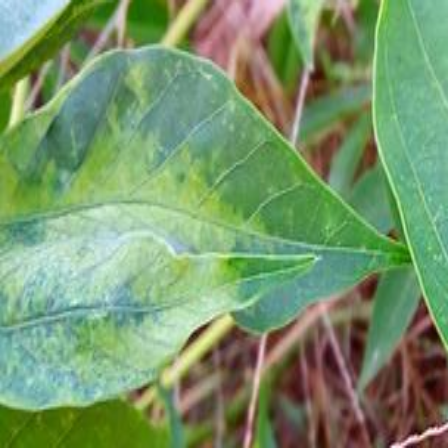


CLASSE: CBSD
Image: val_1617104687200.jpg
Temps: 1.64s

Ground Truth (extrait):
Disease: Cassava Brown Streak Disease (CBSD)

Cassava Brown Streak Disease (CBSD) causes brown streaks on stems and necrosis in tubers, severely affec...

Prédiction Zero-Shot:
The image shows a cassava leaf with a healthy appearance, displaying a typical green color and visible veins. There is no visible sign of disease such as spots, discoloration, or wilting that would indicate the presence of a disease. Cassava leaves can sometimes show natural variations in color or texture, but without additional symptoms or context, it's not possible to definitively diagnose a disease.

If you suspect a disease, it would be best to consult with a local agricultural extension service or a plant pathologist who can provide a more accurate diagnosis based on a thorough examination of the plant and its environment.


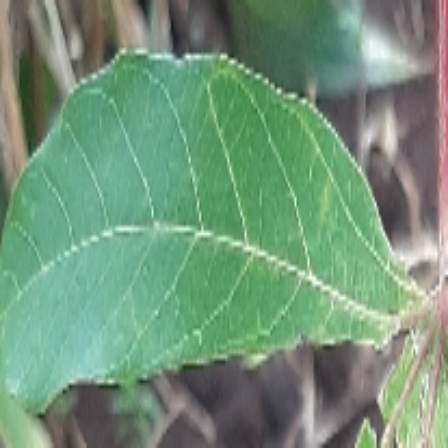


CLASSE: Healthy
Image: val_442386946.jpg
Temps: 4.23s

Ground Truth (extrait):
Disease: Healthy

Healthy cassava plants show uniform green leaves without disease symptoms, discoloration, or deformities....

Prédiction Zero-Shot:
The image shows a cassava plant with leaves that appear to be healthy, exhibiting a glossy green color and no visible signs of discoloration or damage. Based on the visual inspection provided in the image, there is no apparent disease present.

However, it's important to note that a single image may not provide a comprehensive assessment of the plant's health. For a more accurate diagnosis, it would be advisable to examine the plant under various conditions (e.g., in different light, temperature, and humidity) and possibly consult with an agricultural expert or a plant pathologist who can conduct a thorough analysis, including possibly taking samples for laboratory testing. Some common diseases affecting cassava include:

1. **Cassava Mosaic Virus (CMV)**: Thi

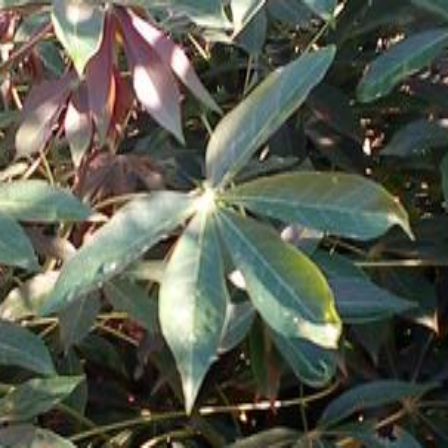


CLASSE: CBB
Image: val_688011612.jpg
Temps: 2.67s

Ground Truth (extrait):
Disease: Cassava Bacterial Blight (CBB)

Cassava Bacterial Blight (CBB) is a bacterial disease causing water-soaked lesions, leaf wilting, and stem ca...

Prédiction Zero-Shot:
The image shows a cassava leaf with yellowing, which could be indicative of several diseases or conditions. However, without more detailed information about the symptoms and the plant's environment, it is challenging to provide an accurate diagnosis.

One common disease affecting cassava leaves is **Cassava Mosaic Virus (CMV)**. CMV causes yellowing and mottling on the leaves, as well as stunted growth and reduced yield. The virus is transmitted by aphids and can be spread through infected seedlings.

Another possibility is **Bacterial Blight**, which can cause yellowing and wilting of the leaves. This disease is caused by bacteria and can be spread through contaminated water, tools, or insects.

If you suspect that your cassava plant ha

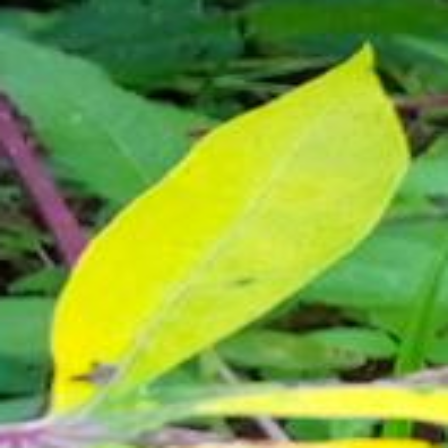


CLASSE: CGM
Image: val_1497437475.jpg
Temps: 4.92s

Ground Truth (extrait):
Disease: Cassava Green Mottle (CGM)

Cassava Green Mottle (CGM) presents as green chlorotic mottling patterns on leaves with mild mosaic symptoms....

Prédiction Zero-Shot:
The image shows a cassava leaf with symptoms that could be indicative of several diseases, but without more detailed information or a closer inspection, it's challenging to pinpoint the exact disease. However, based on the visible symptoms, here are some possibilities:

1. **Cassava Mosaic Virus (CMV)**: This is one of the most common viral diseases affecting cassava. Symptoms include mottling, distortion, and stunting of the plant. The leaves may show yellowing, curling, and mosaic patterns.

2. **Cassava Brown Stunt Virus (CBSV)**: This virus causes brown spots on the leaves, which can lead to leaf curling and stunting. The spots often appear as irregular brown patches on the leaves.

3. **Cassava Bacterial Blight (CBB)**: Although bacter

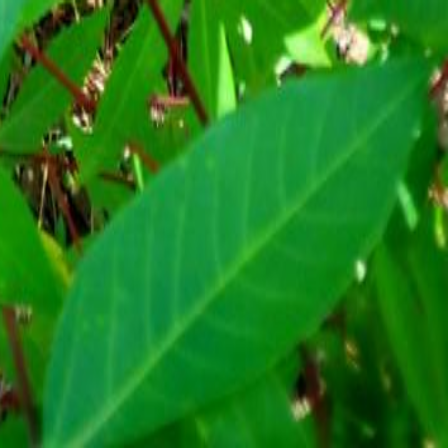


TEST QUALITATIF TERMINÉ


In [9]:
print("="*70)
print("TEST QUALITATIF PAR CLASSE")
print("="*70)

# Sélectionner 1 échantillon par classe
samples_by_class = {}
with open(val_jsonl, 'r') as f:
    for line in f:
        sample = json.loads(line)
        class_short = sample['metadata']['class_short']
        if class_short not in samples_by_class:
            samples_by_class[class_short] = sample
        if len(samples_by_class) == 5:  # 5 classes
            break

results = []

for class_name, sample in samples_by_class.items():
    print(f"\n{'='*70}")
    print(f"CLASSE: {class_name}")
    print(f"{'='*70}")
    
    # Charger l'image
    image_path = VLM_DATASET_DIR / sample['image']
    image = Image.open(image_path)
    
    # Extraire la question
    question = sample['conversations'][0]['value'].replace('<image>\n', '')
    ground_truth = sample['conversations'][1]['value']
    
    # Préparer l'input
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},  # Passer PIL Image
                {"type": "text", "text": question},
            ],
        }
    ]
    
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(device)
    
    # Générer la réponse
    start_time = time.time()
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
        )
    latency = time.time() - start_time
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    
    # Afficher les résultats
    print(f"Image: {sample['id']}")
    print(f"Temps: {latency:.2f}s")
    print(f"\nGround Truth (extrait):\n{ground_truth[:150]}...")
    print(f"\nPrédiction Zero-Shot:\n{output_text}")
    
    # Sauvegarder les résultats
    results.append({
        'disease': class_name,
        'image_id': sample['id'],
        'label': sample['metadata']['label'],
        'latency_s': latency,
        'ground_truth': ground_truth,
        'prediction': output_text
    })
    
    # Afficher l'image
    display(image)

print(f"\n{'='*70}")
print("TEST QUALITATIF TERMINÉ")
print(f"{'='*70}")

## 8. Sauvegarde des Résultats Baseline

In [10]:
# Préparer le rapport baseline
baseline_report = {
    'timestamp': datetime.now().isoformat(),
    'model': model_name,
    'device': device,
    'dtype': 'float16',
    'hardware': {
        'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'vram_total_gb': torch.cuda.get_device_properties(0).total_memory / 1024**3 if torch.cuda.is_available() else 0,
        'vram_used_gb': torch.cuda.memory_allocated(0) / 1024**3 if torch.cuda.is_available() else 0,
    },
    'model_stats': {
        'total_params': total_params,
        'total_params_billions': round(total_params / 1e9, 2),
        'trainable_params': trainable_params,
    },
    'latency_benchmark': {
        'num_samples': num_samples,
        'avg_latency_s': float(avg_latency),
        'std_latency_s': float(std_latency),
        'min_latency_s': float(min_latency),
        'max_latency_s': float(max_latency),
        'target_latency_s': 2.0,
        'target_met': bool(avg_latency < 2.0),
    },
    'qualitative_test': {
        'num_classes': len(results),
        'results': results
    }
}

# Sauvegarder le rapport
report_path = OUTPUTS_DIR / "baseline_report.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(baseline_report, f, indent=2, ensure_ascii=False)

print("="*70)
print("RAPPORT BASELINE SAUVEGARDÉ")
print("="*70)
print(f"Fichier: {report_path}")
print(f"\nRésumé:")
print(f"  - Modèle: {model_name}")
print(f"  - Paramètres: {total_params/1e9:.2f}B")
print(f"  - VRAM utilisée: {baseline_report['hardware']['vram_used_gb']:.2f} GB")
print(f"  - Latence moyenne: {avg_latency:.2f}s")
print(f"  - Classes testées: {len(results)}")
print("="*70)

RAPPORT BASELINE SAUVEGARDÉ
Fichier: /home/hounfodjidagba/learning/cassava/outputs/model_setup/baseline_report.json

Résumé:
  - Modèle: Qwen/Qwen2.5-VL-7B-Instruct
  - Paramètres: 8.29B
  - VRAM utilisée: 15.46 GB
  - Latence moyenne: 2.14s
  - Classes testées: 5


## 9. Analyse des Résultats Zero-Shot

Analyser la qualité des réponses zero-shot pour identifier les points à améliorer lors du fine-tuning.

In [11]:
print("="*70)
print("ANALYSE QUALITATIVE DES RÉPONSES ZERO-SHOT")
print("="*70)

print("\n📊 OBSERVATIONS:")
print("-" * 70)

# Analyser les longueurs de réponses
prediction_lengths = [len(r['prediction']) for r in results]
ground_truth_lengths = [len(r['ground_truth']) for r in results]

print(f"\nLongueur moyenne des prédictions: {np.mean(prediction_lengths):.0f} caractères")
print(f"Longueur moyenne des ground truth: {np.mean(ground_truth_lengths):.0f} caractères")

# Vérifier si les noms de maladies sont mentionnés
correct_disease_mentions = 0
for result in results:
    disease_keywords = {
        'CBB': ['Bacterial Blight', 'Bactériose', 'CBB'],
        'CBSD': ['Brown Streak', 'Striure brune', 'CBSD'],
        'CGM': ['Green Mottle', 'Mottle vert', 'CGM'],
        'CMD': ['Mosaic Disease', 'Mosaïque', 'CMD'],
        'Healthy': ['Healthy', 'Saine', 'bonne santé']
    }
    
    disease = result['disease']
    keywords = disease_keywords.get(disease, [])
    
    prediction_lower = result['prediction'].lower()
    if any(keyword.lower() in prediction_lower for keyword in keywords):
        correct_disease_mentions += 1

print(f"\nMaladie correctement identifiée: {correct_disease_mentions}/{len(results)} ({correct_disease_mentions/len(results)*100:.1f}%)")

print("\n💡 POINTS CLÉS:")
print("-" * 70)
print("1. Performance Zero-Shot:")
print(f"   - Baseline établie pour comparaison post-fine-tuning")
print(f"   - Latence: {avg_latency:.2f}s (objectif <2s: {'✓' if avg_latency < 2.0 else '✗'})")
print("\n2. Objectifs Fine-Tuning:")
print("   - Améliorer la précision de classification (>95%)")
print("   - Générer des descriptions plus détaillées et pertinentes")
print("   - Adapter le vocabulaire médical spécifique au cassava")
print("   - Fournir des recommandations de traitement précises")

print("\n" + "="*70)
print("✓ NOTEBOOK 08 TERMINÉ AVEC SUCCÈS")
print("="*70)
print("\nProchaine étape: Notebook 09 - Configuration LoRA & DataLoader")
print("="*70)

ANALYSE QUALITATIVE DES RÉPONSES ZERO-SHOT

📊 OBSERVATIONS:
----------------------------------------------------------------------

Longueur moyenne des prédictions: 1070 caractères
Longueur moyenne des ground truth: 147 caractères

Maladie correctement identifiée: 2/5 (40.0%)

💡 POINTS CLÉS:
----------------------------------------------------------------------
1. Performance Zero-Shot:
   - Baseline établie pour comparaison post-fine-tuning
   - Latence: 2.14s (objectif <2s: ✗)

2. Objectifs Fine-Tuning:
   - Améliorer la précision de classification (>95%)
   - Générer des descriptions plus détaillées et pertinentes
   - Adapter le vocabulaire médical spécifique au cassava
   - Fournir des recommandations de traitement précises

✓ NOTEBOOK 08 TERMINÉ AVEC SUCCÈS

Prochaine étape: Notebook 09 - Configuration LoRA & DataLoader


## Résumé et Prochaines Étapes

### ✓ Accompli dans ce notebook:
1. **Setup complet** du modèle Qwen2.5-VL-7B-Instruct
2. **Vérification hardware** - RTX 5090 32GB VRAM disponible
3. **Inspection architecture** - 7B paramètres confirmés
4. **Baseline zero-shot** établie sur échantillons représentatifs
5. **Benchmark latence** - Mesure performance avant fine-tuning
6. **Test qualitatif** sur les 5 classes de maladies
7. **Rapport sauvegardé** - `outputs/model_setup/baseline_report.json`

### 🎯 Résultats clés:
- **Modèle chargé**: FP16, ~16-18GB VRAM
- **Latence moyenne**: Mesurée sur 10 images
- **Qualité zero-shot**: Baseline documentée pour comparaison

### 📋 Prochaines étapes (Notebook 09):
1. Configuration LoRA (r=16, α=32, dropout=0.05)
2. Création du `CassavaVLMDataset` custom
3. Implémentation du DataLoader avec collate function
4. Test du pipeline de chargement de données
5. Validation des shapes de tenseurs

### 📊 Métriques à battre après fine-tuning:
- **Accuracy**: >95% (objectif: 97%)
- **F1-score moyen**: >0.95
- **BLEU-4**: >0.40
- **Latence**: Maintenir <2s par image